# KNN Classification — 4QMV Features

Pipeline:
1. Load `poc_abs_quadran_sum.xlsx` (per-frame)
2. Pisahkan external test set (per-subject)
3. Train SVM via `build_knn()` — Pipeline(Scaler → SVM balanced)
4. Split 60/40, 70/30, 80/20, 90/10
5. Metrik: UF1 (macro F1), UAR (macro recall), accuracy
6. External test


In [1]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "comparasion":
    ROOT = ROOT.parent
elif ROOT.name in {"lstm", "svm", "knn"}:
    ROOT = ROOT.parent.parent.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from comparasion.core.models import build_knn, fit_model, predict


## 1. Load Data

In [3]:
FEATURE_PATH = Path("comparasion/output_casme2/features/poc_abs_quadran_sum.xlsx")

df = pd.read_excel(FEATURE_PATH)
print(f"Shape: {df.shape}")

META_COLS = ["emotion", "subject", "clip", "frame", "label"]
feat_cols = [c for c in df.columns if c not in META_COLS]

print(f"Features: {len(feat_cols)}")
print(f"\nLabel dist:")
print(df["label"].value_counts())

Shape: (1151, 145)
Features: 140

Label dist:
label
Surprise     324
Happiness    305
Sadness      267
Disgust      255
Name: count, dtype: int64


## 2. External Test Set

Pisahkan 2 subject per emotion → external test. Sisanya = main (train+val).


In [4]:
SEED = 42

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
print(f"Classes: {list(le.classes_)}")

rng = np.random.RandomState(SEED)
external_subjects = set()

for emo in df["emotion"].unique():
    subjects_in_emo = df[df["emotion"] == emo]["subject"].unique()
    n_ext = min(2, len(subjects_in_emo))
    chosen = rng.choice(subjects_in_emo, size=n_ext, replace=False)
    external_subjects.update(chosen)

print(f"External subjects ({len(external_subjects)}): {sorted(external_subjects)}")

df_ext = df[df["subject"].isin(external_subjects)].copy()
df_main = df[~df["subject"].isin(external_subjects)].copy()

print(f"\nMain: {len(df_main)} rows")
print(f"External: {len(df_ext)} rows")
print(f"\nMain label dist:")
print(df_main["label"].value_counts())

Classes: ['Disgust', 'Happiness', 'Sadness', 'Surprise']
External subjects (7): [np.int64(5), np.int64(6), np.int64(14), np.int64(17), np.int64(19), np.int64(20), np.int64(24)]

Main: 344 rows
External: 807 rows

Main label dist:
label
Happiness    145
Disgust      115
Surprise      45
Sadness       39
Name: count, dtype: int64


In [5]:
X_main = df_main[feat_cols].values
y_main = df_main["label_enc"].values

X_ext = df_ext[feat_cols].values
y_ext = df_ext["label_enc"].values

print(f"X_main: {X_main.shape}")
print(f"X_ext:  {X_ext.shape}")

X_main: (344, 140)
X_ext:  (807, 140)


## 3. Training — Tiap Split Terpisah


### Split 60/40

In [6]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.4, stratify=y_main, random_state=SEED
)

pipe = build_knn()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_4QMV_60/40")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_60_40 = {
    "split": "60/40", "test_size": 0.4,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 206 rows, Val: 138 rows
Train — Acc: 0.8398  UF1: 0.8563  UAR: 0.8558
Val   — Acc: 0.7101  UF1: 0.7095  UAR: 0.7001

              precision    recall  f1-score   support

     Disgust       0.89      0.52      0.66        46
   Happiness       0.67      0.86      0.75        58
     Sadness       1.00      0.75      0.86        16
    Surprise       0.50      0.67      0.57        18

    accuracy                           0.71       138
   macro avg       0.76      0.70      0.71       138
weighted avg       0.76      0.71      0.71       138



### Split 70/30

In [7]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.3, stratify=y_main, random_state=SEED
)

pipe = build_knn()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_4QMV_70/30")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_70_30 = {
    "split": "70/30", "test_size": 0.3,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 240 rows, Val: 104 rows
Train — Acc: 0.8375  UF1: 0.8463  UAR: 0.8434
Val   — Acc: 0.7115  UF1: 0.7260  UAR: 0.7259

              precision    recall  f1-score   support

     Disgust       0.79      0.66      0.72        35
   Happiness       0.68      0.73      0.70        44
     Sadness       1.00      0.75      0.86        12
    Surprise       0.53      0.77      0.62        13

    accuracy                           0.71       104
   macro avg       0.75      0.73      0.73       104
weighted avg       0.74      0.71      0.72       104



### Split 80/20

In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.2, stratify=y_main, random_state=SEED
)

pipe = build_knn()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_4QMV_80/20")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_80_20 = {
    "split": "80/20", "test_size": 0.2,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 275 rows, Val: 69 rows
Train — Acc: 0.8545  UF1: 0.8620  UAR: 0.8651
Val   — Acc: 0.7536  UF1: 0.7628  UAR: 0.7755

              precision    recall  f1-score   support

     Disgust       0.85      0.74      0.79        23
   Happiness       0.75      0.72      0.74        29
     Sadness       1.00      0.75      0.86         8
    Surprise       0.53      0.89      0.67         9

    accuracy                           0.75        69
   macro avg       0.78      0.78      0.76        69
weighted avg       0.78      0.75      0.76        69



### Split 90/10

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.1, stratify=y_main, random_state=SEED
)

pipe = build_knn()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_4QMV_90/10")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_90_10 = {
    "split": "90/10", "test_size": 0.1,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 309 rows, Val: 35 rows
Train — Acc: 0.8673  UF1: 0.8701  UAR: 0.8735
Val   — Acc: 0.7429  UF1: 0.7484  UAR: 0.7417

              precision    recall  f1-score   support

     Disgust       0.73      0.67      0.70        12
   Happiness       0.75      0.80      0.77        15
     Sadness       1.00      0.75      0.86         4
    Surprise       0.60      0.75      0.67         4

    accuracy                           0.74        35
   macro avg       0.77      0.74      0.75        35
weighted avg       0.75      0.74      0.74        35



In [10]:
results = [result_60_40, result_70_30, result_80_20, result_90_10]

## 4. Tabel Perbandingan

In [11]:
comparison = pd.DataFrame([{
    "Split": r["split"],
    "Train Acc": f'{r["train_acc"]:.4f}',
    "Val Acc": f'{r["val_acc"]:.4f}',
    "Train UF1": f'{r["train_f1"]:.4f}',
    "Val UF1": f'{r["val_f1"]:.4f}',
    "Train UAR": f'{r["train_uar"]:.4f}',
    "Val UAR": f'{r["val_uar"]:.4f}',
} for r in results])

print(comparison.to_string(index=False))
comparison

Split Train Acc Val Acc Train UF1 Val UF1 Train UAR Val UAR
60/40    0.8398  0.7101    0.8563  0.7095    0.8558  0.7001
70/30    0.8375  0.7115    0.8463  0.7260    0.8434  0.7259
80/20    0.8545  0.7536    0.8620  0.7628    0.8651  0.7755
90/10    0.8673  0.7429    0.8701  0.7484    0.8735  0.7417


,Split,Train Acc,Val Acc,Train UF1,Val UF1,Train UAR,Val UAR
0,60/40,0.8398,0.7101,0.8563,0.7095,0.8558,0.7001
1,70/30,0.8375,0.7115,0.8463,0.7260,0.8434,0.7259
2,80/20,0.8545,0.7536,0.8620,0.7628,0.8651,0.7755
3,90/10,0.8673,0.7429,0.8701,0.7484,0.8735,0.7417


## 5. Confusion Matrix per Split

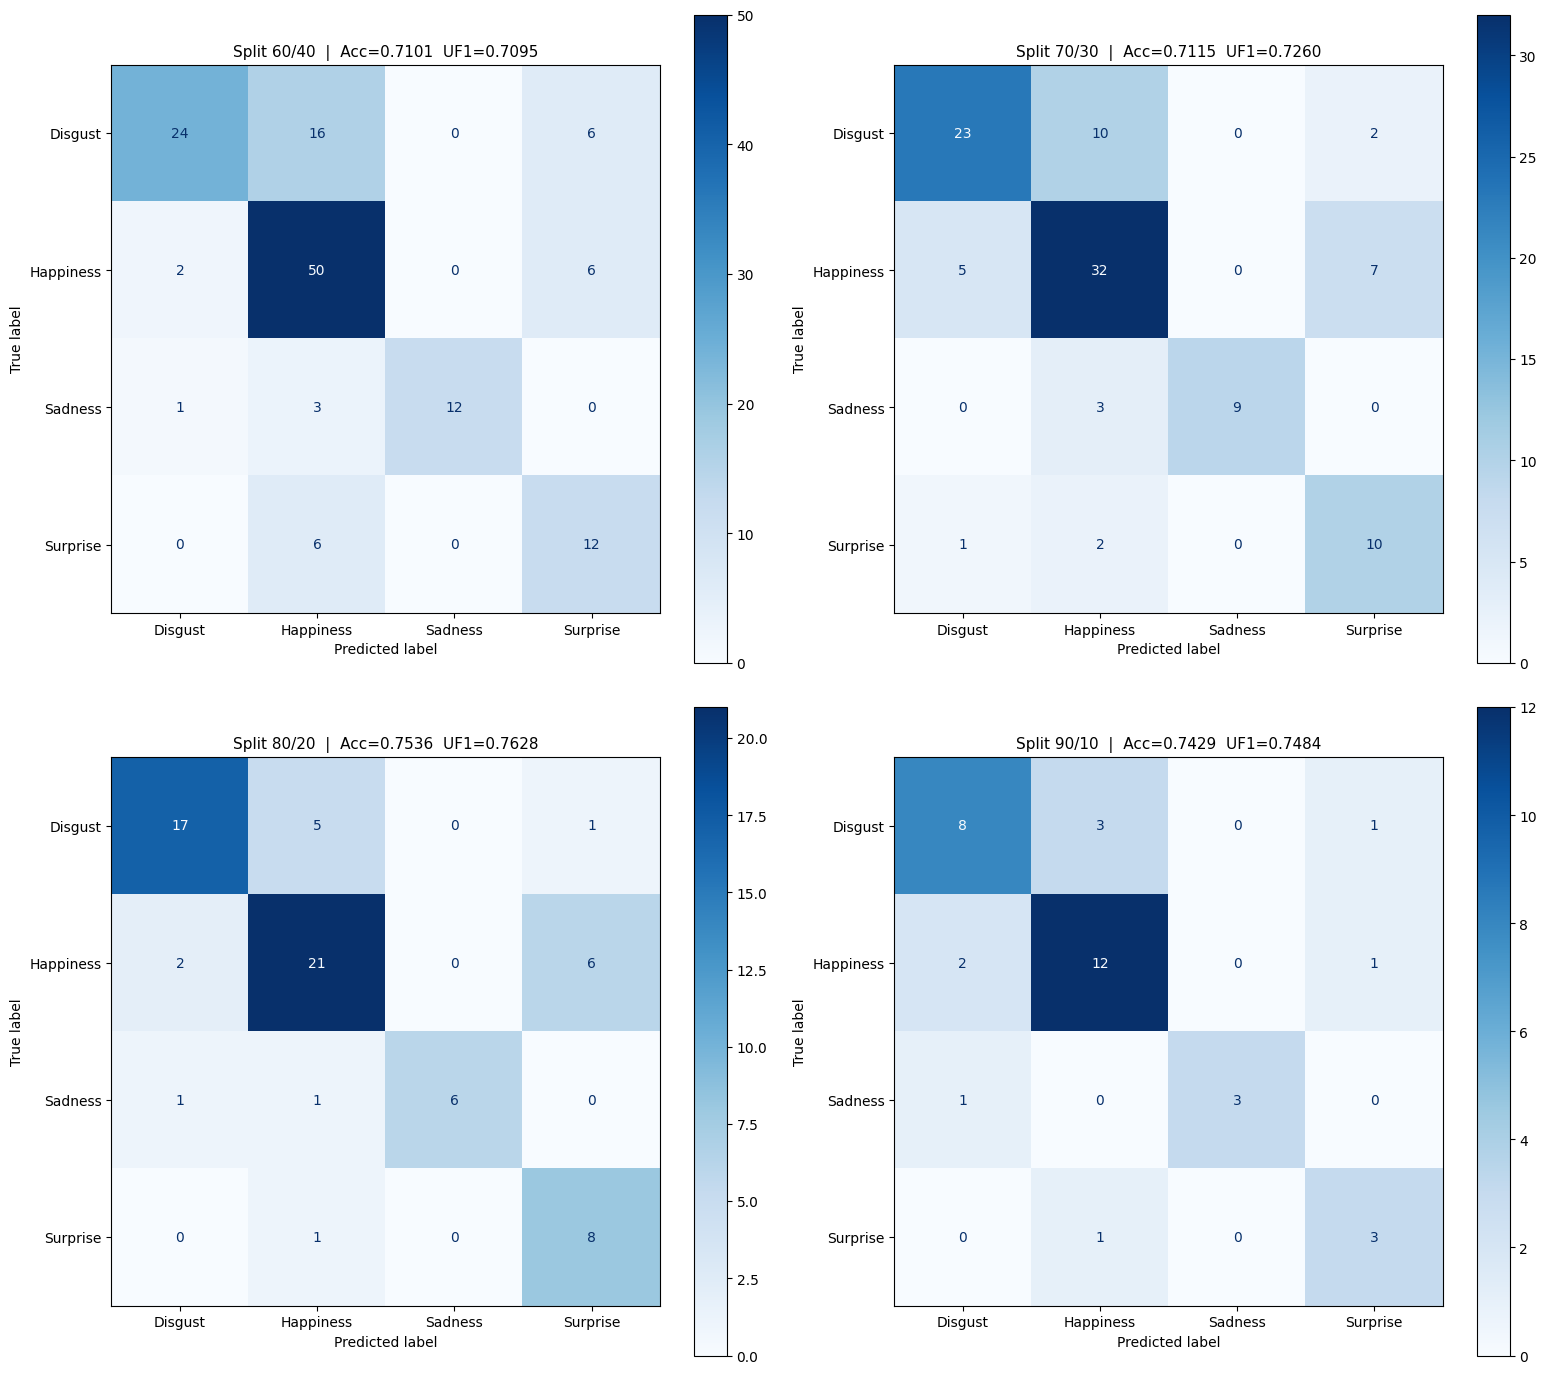

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, r in zip(axes.flatten(), results):
    cm = confusion_matrix(r["y_val"], r["y_val_pred"])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f'Split {r["split"]}  |  Acc={r["val_acc"]:.4f}  UF1={r["val_f1"]:.4f}', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Best Split

In [13]:
best = max(results, key=lambda r: r["val_f1"])
print(f"Best split: {best['split']} (Val UF1={best['val_f1']:.4f})\n")
print(classification_report(best["y_val"], best["y_val_pred"], target_names=le.classes_))

Best split: 80/20 (Val UF1=0.7628)

              precision    recall  f1-score   support

     Disgust       0.85      0.74      0.79        23
   Happiness       0.75      0.72      0.74        29
     Sadness       1.00      0.75      0.86         8
    Surprise       0.53      0.89      0.67         9

    accuracy                           0.75        69
   macro avg       0.78      0.78      0.76        69
weighted avg       0.78      0.75      0.76        69



## 7. External Test

In [14]:
y_ext_pred = predict(best["model"], X_ext)

ext_acc = accuracy_score(y_ext, y_ext_pred)
ext_f1 = f1_score(y_ext, y_ext_pred, average="macro")
ext_uar = recall_score(y_ext, y_ext_pred, average="macro")

print(f"External Test — Acc: {ext_acc:.4f}  UF1: {ext_f1:.4f}  UAR: {ext_uar:.4f}")
print(f"\n{classification_report(y_ext, y_ext_pred, target_names=le.classes_)}")

External Test — Acc: 0.3073  UF1: 0.3018  UAR: 0.3453

              precision    recall  f1-score   support

     Disgust       0.22      0.30      0.25       140
   Happiness       0.25      0.70      0.37       160
     Sadness       0.95      0.24      0.38       228
    Surprise       0.35      0.14      0.20       279

    accuracy                           0.31       807
   macro avg       0.44      0.35      0.30       807
weighted avg       0.48      0.31      0.29       807



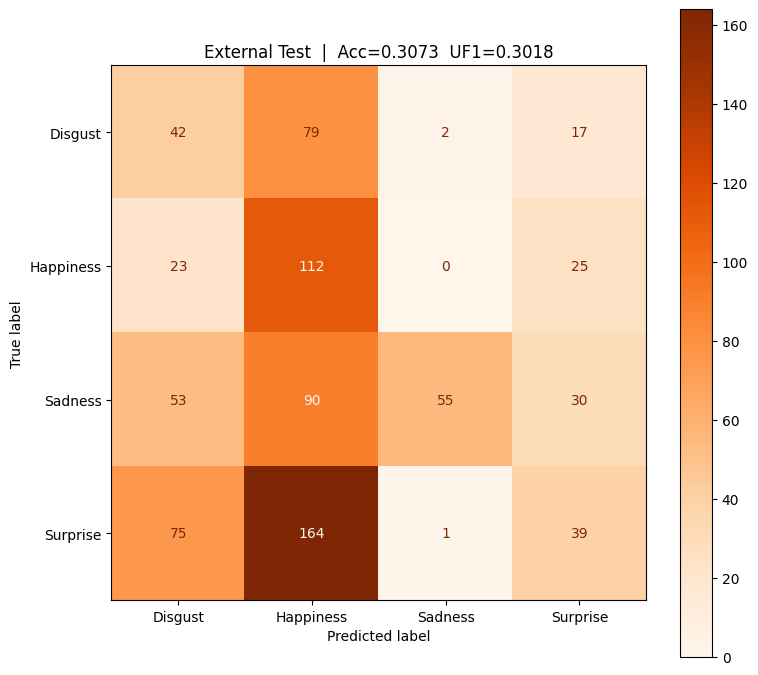

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
cm_ext = confusion_matrix(y_ext, y_ext_pred)
ConfusionMatrixDisplay(cm_ext, display_labels=le.classes_).plot(ax=ax, cmap="Oranges", values_format="d")
ax.set_title(f"External Test  |  Acc={ext_acc:.4f}  UF1={ext_f1:.4f}", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Ringkasan

In [16]:
summary = pd.DataFrame([{
    "Split": r["split"],
    "Train Acc": f'{r["train_acc"]:.4f}',
    "Val Acc": f'{r["val_acc"]:.4f}',
    "Val UF1": f'{r["val_f1"]:.4f}',
    "Val UAR": f'{r["val_uar"]:.4f}',
} for r in results])

summary = pd.concat([summary, pd.DataFrame([{
    "Split": f"External ({best['split']})",
    "Train Acc": "-",
    "Val Acc": f"{ext_acc:.4f}",
    "Val UF1": f"{ext_f1:.4f}",
    "Val UAR": f"{ext_uar:.4f}",
}])], ignore_index=True)

print(summary.to_string(index=False))
summary

           Split Train Acc Val Acc Val UF1 Val UAR
           60/40    0.8398  0.7101  0.7095  0.7001
           70/30    0.8375  0.7115  0.7260  0.7259
           80/20    0.8545  0.7536  0.7628  0.7755
           90/10    0.8673  0.7429  0.7484  0.7417
External (80/20)         -  0.3073  0.3018  0.3453


,Split,Train Acc,Val Acc,Val UF1,Val UAR
0,60/40,0.8398,0.7101,0.7095,0.7001
1,70/30,0.8375,0.7115,0.7260,0.7259
2,80/20,0.8545,0.7536,0.7628,0.7755
3,90/10,0.8673,0.7429,0.7484,0.7417
4,External (80/20),-,0.3073,0.3018,0.3453
